# Assignment 4
### Do three of four.

### Exercise 1: Contingent Comparisons
- Load the Minnesota use of force data.
- Bootstrap the proportion of missing values for `subject_injury` for each race, and plot the results with grouped KDE and ECDF plots
- Describe what you see. When we consider second order uncertainty, how similar or different are the sampling distributions of these proportions? 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [11]:
minnesota = pd.read_csv('mn_police_use_of_force.csv')
minnesota.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


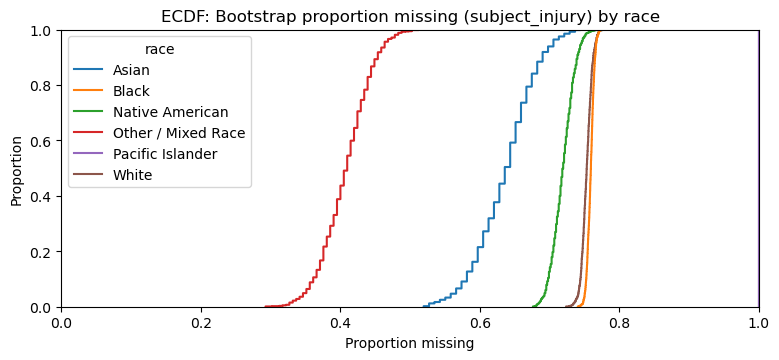

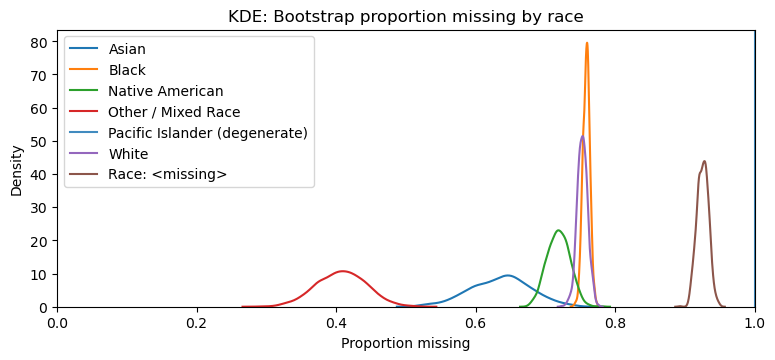

In [5]:
S = 1000

# Bootstrap estimates by race
rows = []
for race, g in minnesota.groupby('race', dropna=False):
    s = g['subject_injury']
    p = s.isna().mean()
    est = np.full(S, p) if (p==0 or p==1) else np.array(
        [s.sample(frac=1, replace=True).isna().mean() for _ in range(S)]
    )
    rows.append(pd.DataFrame({'race': race, 'estimate': est}))
long = pd.concat(rows, ignore_index=True)

# ECDF
plt.figure(figsize=(9,3.6))
sns.ecdfplot(data=long, x='estimate', hue='race')
plt.title('ECDF: Bootstrap proportion missing (subject_injury) by race')
plt.xlabel('Proportion missing'); plt.xlim(0,1); plt.show()

# KDE
plt.figure(figsize=(9,3.6))
for r, sub in long.groupby('race', dropna=False):
    e = sub['estimate'].to_numpy()
    label = 'Race: <missing>' if pd.isna(r) else str(r)
    if np.nanstd(e) == 0:
        plt.axvline(e[0], alpha=0.85, label=f'{label} (degenerate)')
    else:
        sns.kdeplot(x=e, label=label, common_norm=False)
plt.title('KDE: Bootstrap proportion missing by race')
plt.xlabel('Proportion missing'); plt.xlim(0,1); plt.legend(); plt.show()

**Response:** The bootstrap makes it clear that spread depends on group size. Black and White (the largest groups) are tight around 0.75, while Native American is a bit lower around 0.72, and Asian (~0.64) and Other/Mixed (~0.41) are wider. Pacific Islander hits 1.00 (degenerate) every time, and records with race missing clusters near 0.93. The order barely moves and mostly doesn't overlap: 1.00 (Pacific Islander) --> 0.93 (Missing) --> 0.75 (Black/White) --> 0.72 (Native American) --> 0.64 (Asian) --> 0.41 (Other/Mixed). Smaller groups have more uncertainty, but the differences across groups still stand out.

---

### Exercise 2: Invitation to Inference
- Run the simulation code line by line and comment what each line is doing, or write your own code to do the resampling
- Open the NHANES or Ames prices or College Completion data. Pick a variable and a statistic to compute (e.g. mean, median, variance, IQR)
- Use the `simulate` function from class to get a sample of estimates for your statistic and your data
- Create a new function, `interval(L,H,estimates)`, that computes the $L$-th and $H$-th quantiles for your estimates, $H>L$
- If $L=.05$ and $H=.95$, this is a **90-percent confidence interval**: "For our statistic, this interval captures the true value of the population parameter 90 percent of the time. (We are 90% **confident** that it includes the true value of the parameter, but the probability that the true parameter lies in this interval is 0 or 1.)"
- We will spend much more time on this later in class, but for people who have done hypothesis testing before, you now know how to do it directly from the data: No central limit theorem required.

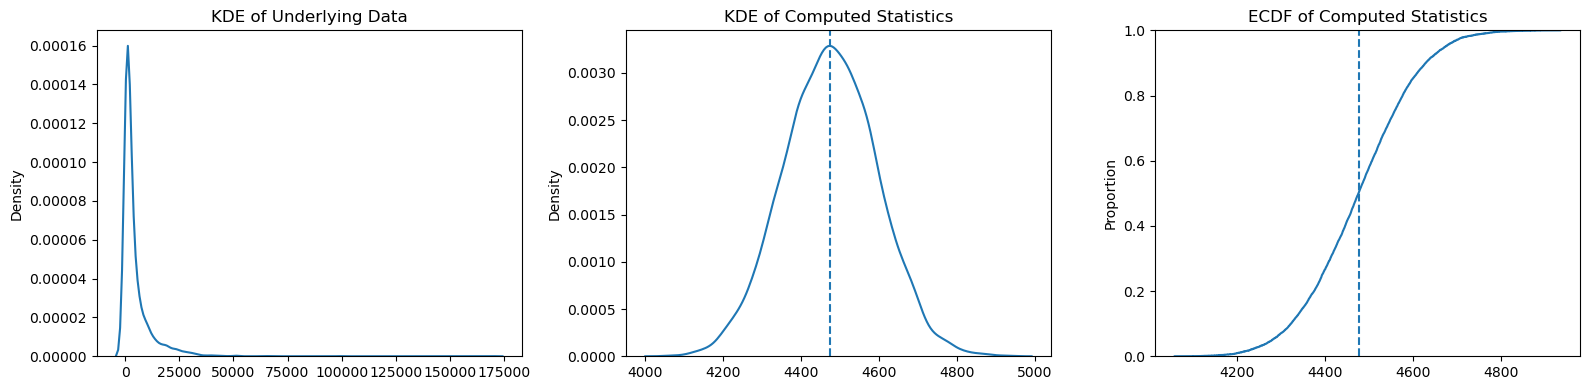

Variance of estimates is: 14290.4748
student_count mean (theta-hat): 4,476.1353
90% bootstrap CI: [4,279.9862, 4,673.4164]
Interpretation: About 90% of such intervals would contain the true population mean for student_count.


In [22]:
df = pd.read_csv("college_completion.csv")

# Our statistic to bootstrap
def stat(x):
    return np.mean(x)

def simulate(var, df, fcn, S=1000, plot=True):
    ''' Bootstrap simulation code. '''
    x = df[var].dropna()

    estimates = []
    rng = np.random.default_rng(7)
    n = x.shape[0]
    x_vals = x.to_numpy()

    for s in range(S):
        # Draw a new sample, with replacement (vectorized by indices)
        idx = rng.integers(0, n, size=n)
        x_s = x_vals[idx]
        # Compute statistic:
        stat_s = fcn(x_s)
        # Append estimate:
        estimates.append(stat_s)

    estimates = np.array(estimates)  # Convert list to numpy array

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        sns.kdeplot(x=x_vals, ax=axes[0]).set(title='KDE of Underlying Data')
        sns.kdeplot(x=estimates, ax=axes[1]).set(title='KDE of Computed Statistics')
        axes[1].axvline(x=fcn(x_vals), linestyle='--')

        sns.ecdfplot(x=estimates, ax=axes[2]).set(title='ECDF of Computed Statistics')
        axes[2].axvline(x=fcn(x_vals), linestyle='--')

        plt.tight_layout(); plt.show()
        print(f'Variance of estimates is: {np.var(estimates, ddof=1):.4f}')
    return estimates

# 3) Percentile CI helper (L,H can be 0–1 or 0–100)
def interval(L, H, estimates):
    Lp = 100*L if 0 <= L <= 1 else L
    Hp = 100*H if 0 <= H <= 1 else H
    lo, hi = np.percentile(estimates, [Lp, Hp])
    return float(lo), float(hi)

var = 'student_count'
S = 10_000
estimates = simulate(var, df, stat, S=S, plot=True)

theta_hat = stat(df[var].dropna().to_numpy())
ci90 = interval(0.05, 0.95, estimates)

print(f'{var} mean (theta-hat): {theta_hat:,.4f}')
print(f'90% bootstrap CI: [{ci90[0]:,.4f}, {ci90[1]:,.4f}]')
print('Interpretation: About 90% of such intervals would contain the true population mean for student_count.')


---

### Exercise 3: Intro to A/B Testing
- Go here, and read about this study: https://www.clinicaltrials.gov/study/NCT01985360
- Read the Study Overview and explain what the goal of the trial is 
- Read the Study Plan and explain how it was designed and why -- there's lots of medical jargon, but the main point is how patients were assigned to interventions. 
- Read the Results Posted: Go to **Outcome Measures**. Explain how table 1 ("Incidence of Death from Any Cause or Myocardial Infarction") is a contingency table. These are the data for this exercise.
- What is the difference in surival rates between the invasive strategy and the conservative strategy?
- Bootstrap the survival rates for the two groups, and plot them as KDEs and ECDFs against one another
- Bootstrap the difference in surival rates, and plot it as a KDE and ECDF
- Is this an effective health intervention? Explain your answer clearly

This would be what CS people call **A/B testing** and everyone else called a **randomized controlled trial**: Using randomized assignment to detect the difference in outcomes between two groups. (We've just done a non-parametric version of a two-sample t-test.)

**Goal:** Test whether starting with initial invasive strategy is better than conservative, meds-first strategy for patients with stable ischemic heart disease, moderate-severe ischemia on stress testing, and advanced chronic kidney disease. Ultimately, wanting to test which approach leads to better patient outcomes in the high-risk group.

**Design History:** Patients with stable coronary disease, moderate-severe ischemia, and advanced CKD were randomized 1:1 into two parallel groups before any catheterization. One group followed an invasive strategy (routine coronary angiography with PCI/CABG if feasible) plus optimal medical therapy; the other followed a conservative strategy (optimal medical therapy first, angiography only if symptoms or events persisted). Randomization balances patient factors across groups and isolates the effect of the strategy itself (early cath vs meds-first). Assigning before cath also cleanly separates contrast exposure, important for CKD safety, so difference in outcomes can be attributed to the assigned approach.

**Outcome Measures:** Table 1 is a simple 2x2 contingency table. The rows are the two randomized groups—invasive and conservative. The columns are the outcomes: had the primary event (death or nonfatal MI) or no event. Each cell is a patient count. From those counts you get each group’s event rate and survival rate, then compare them. These are the data we use for the bootstrap.

**Survival Rate Differences:** Survival is about the same in both groups. Invasive is ~63.6% and conservative is ~63.3%, a difference of roughly 0.3. The gap is not clinically meaningful.

In [37]:
n_inv, n_con = 388, 389
e_inv, e_con = 141, 143  # 1=event, 0=no event
con_df = pd.DataFrame({'event': np.r_[np.ones(e_con, int), np.zeros(n_con - e_con, int)]})

def stat(x):
    return 1.0 - np.mean(x)


def simulate(var, df, fcn, S=1000, plot=True):
    ''' Bootstrap simulation code. '''
    x = df[var].dropna()
    estimates = []
    for s in range(S):
        x_s = x.sample(frac=1.0, replace=True)
        stat_s = fcn(x_s)
        estimates.append(stat_s)
    estimates = np.array(estimates)

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        sns.kdeplot(x=x, ax=axes[0]).set(title='KDE of Underlying Data')
        sns.kdeplot(x=estimates, ax=axes[1]).set(title='KDE of Computed Statistics')
        axes[1].axvline(x=fcn(x), linestyle='--')
        sns.ecdfplot(x=estimates, ax=axes[2]).set(title='ECDF of Computed Statistics')
        axes[2].axvline(x=fcn(x), linestyle='--')
        plt.tight_layout(); plt.show()
        print(f'Variance of estimates is: {np.var(estimates, ddof=1):.6f}')
    return estimates

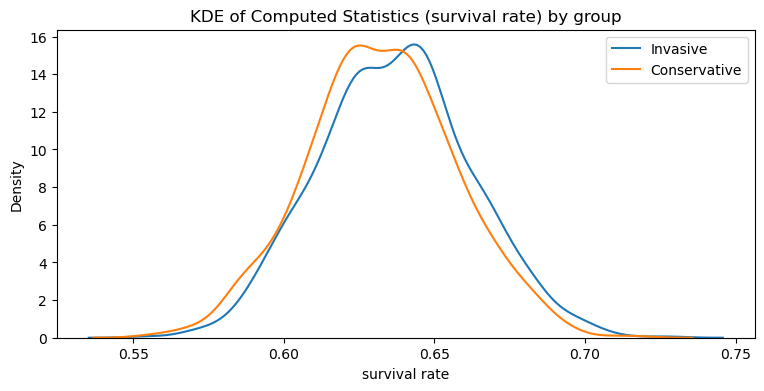

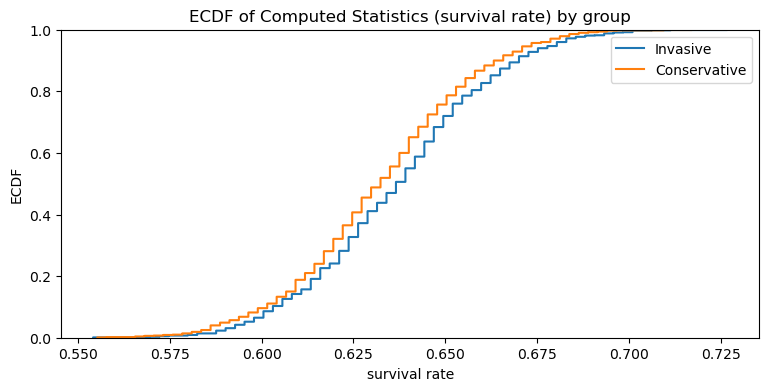

In [38]:
# Boostrap of survival rates
S = 1000
boot_inv = simulate('event', inv_df, stat, S=S, plot=False)
boot_con = simulate('event', con_df, stat, S=S, plot=False)

# KDE overlay (group vs group)
plt.figure(figsize=(9,4))
sns.kdeplot(x=boot_inv, label='Invasive')
sns.kdeplot(x=boot_con, label='Conservative')
plt.title('KDE of Computed Statistics (survival rate) by group')
plt.xlabel('survival rate'); plt.legend(); plt.show()

# ECDF overlay (group vs group)
plt.figure(figsize=(9,4))
sns.ecdfplot(x=boot_inv, label='Invasive')
sns.ecdfplot(x=boot_con, label='Conservative')
plt.title('ECDF of Computed Statistics (survival rate) by group')
plt.xlabel('survival rate'); plt.ylabel('ECDF'); plt.legend(); plt.show()

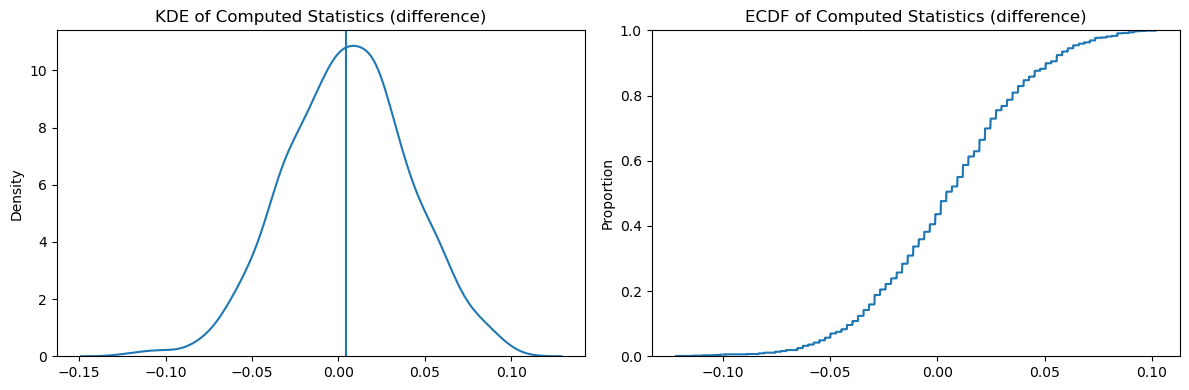

In [42]:
# Bootstrap difference in survival rates
def simulate_diff(var, dfA, dfB, fcn, S=1000, plot=True):
    estimates = []
    for s in range(S):
        a = dfA[var].sample(frac=1.0, replace=True)
        b = dfB[var].sample(frac=1.0, replace=True)
        estimates.append(fcn(a) - fcn(b))
    estimates = np.array(estimates)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.kdeplot(x=estimates, ax=axes[0]).set(title='KDE of Computed Statistics (difference)')
        axes[0].axvline(x=np.median(estimates), linestyle='-')
        sns.ecdfplot(x=estimates, ax=axes[1]).set(title='ECDF of Computed Statistics (difference)')
        plt.tight_layout(); plt.show()
        
    return estimates

boot_diff = simulate_diff('event', inv_df, con_df, stat, S=S, plot=True)

**Observation:** Table 1 is a simple 2×2 contingency table: the rows are the two randomly assigned groups (Invasive vs Conservative) and the columns are the two outcome categories for the primary endpoint (Had event = death or nonfatal MI vs No event). Each cell holds a count of patients in that combination (e.g., “Invasive + Event”). Row totals give arm sizes, column totals give total events/survivors, and from those counts you compute each arm’s event rate (events ÷ arm total) and survival rate (1 − event rate), then the difference in rates.

---

### Exercise 4: Prediction Uncertainty
- Pick a dataset and two continuous variables.
- Recall the LCLS estimator:
$$
\hat{y}(z) =  \frac{ \frac{1}{N} \sum_{i=1}^N y_i \times \frac{1}{h}k\left( \frac{z - x_i}{h} \right)}{ \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k\left( \frac{z - x_i}{h} \right)}
$$
with the Epanechnikov kernel and the standard plug-in bandwidth for $h$
- Compute and plot this line for 30 bootstrap samples. Notice where there is a lot of variation in the predictions, versus little variation in the predictions.
- Now, for any $z$, we can bootstrap a distribution of predictions using the above formula. Do this at the 25th percentile, median, and 75th percentile of $X$, and make KDE plots of your results.
- Now, pick a grid for $z$: Obvious choices are all of the unique values in the data, or an equally spaced grid from the minimum value to the maximum value. For each $z$, bootstrap a sample of predictions and compute the .05 and .95 quantiles. Plot these error curves along with your LCLS estimate. Where are your predictions "tight"/reliable? Where are they highly variable/unreliable?